<a href="https://colab.research.google.com/github/SeiDra/lending-club-prediction/blob/scindage-du-notebook-FeatureEngineering%2FModeling/du_sda_ml2_P3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJET 7 : Loan Default Prediction
Partie N°3 — Feature Engineering

Contenu :
- Import des données nettoyées (sortie du P2)
- Identification des types de variables
- Construction de ratios financiers 
- Visualisation de la Corrélation des nouvelles features avec notre target
- Binary Encoding pour les variables binaires
- Train / Test Split stratifié 
- Target Encoding
- Normalisation StandardScaler (fit sur train uniquement)
- Vérifications étendues (NaN, inf, dtypes, distribution)
- Sauvegarde des jeux train/test

In [17]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from category_encoders import TargetEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler

In [18]:
df = pd.read_parquet("DATA/cleaned_data_for_modeling.parquet")

# Lecture du nom de la cible depuis le fichier de configuration
with open("CONFIG/target_config.txt", "r") as f:
    target_col = f.read().strip()

print(f"Cible : {target_col}")
print(f"Dimensions du dataset : {df.shape}")
print(f"\nDistribution de la cible :")
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True) * 100)

Cible : loan_condition_int
Dimensions du dataset : (1518493, 85)

Distribution de la cible :
loan_condition_int
0    1227955
1     290538
Name: count, dtype: int64
loan_condition_int
0    80.866688
1    19.133312
Name: proportion, dtype: float64


In [19]:
df.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'collections_12_mths_ex_med',
       'mths_since_last_major_derog', 'acc_now_delinq', 'tot_coll_amt',
       'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m',
       'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util',
       'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_

###  Identification des types de variables

In [20]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = [col for col in df.select_dtypes(exclude=['object']).columns.tolist()
            if col != target_col]

binary_cat_cols = [col for col in cat_cols if df[col].nunique() <= 2]
multi_cat_cols = [col for col in cat_cols if df[col].nunique() > 2]

print(f"Variables numériques : {len(num_cols)}")
print(f"Variables catégorielles binaires : {len(binary_cat_cols)} → {binary_cat_cols}")
print(f"Variables catégorielles multi : {len(multi_cat_cols)} → {multi_cat_cols}")

Variables numériques : 74
Variables catégorielles binaires : 3 → ['term', 'initial_list_status', 'disbursement_method']
Variables catégorielles multi : 7 → ['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'earliest_cr_line', 'region']


In [21]:
multi_cat_cols

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'earliest_cr_line',
 'region']

In [22]:
binary_cat_cols

['term', 'initial_list_status', 'disbursement_method']

## Construction de ratios financiers



**loan_to_income** : on divise le montant total du prêt par le revenu annuel de l'emprunteur pour mesurer à quel point le prêt est lourd par rapport à ce qu'il gagne.

**installment_to_income** : on divise la mensualité par le revenu mensuel pour savoir quelle proportion de son salaire mensuel est consacrée au remboursement du prêt.

**bal_to_limit** : on divise le solde total actuel par la limite de crédit maximale pour mesurer à quel point l'emprunteur utilise l'ensemble de sa capacité d'emprunt disponible.

**revolving_util_ratio** : on divise le solde revolving (cartes de crédit, lignes de crédit) par la limite revolving totale pour mesurer le taux d'utilisation de ce type de crédit spécifiquement.

**fico_avg** : le dataset fournit une fourchette basse et haute du score de crédit, on prend simplement leur moyenne pour avoir un seul chiffre représentatif du score de crédit de l'emprunteur.

**credit_age_years** : on convertit la date de la première ligne de crédit en un nombre d'années écoulées depuis cette date jusqu'au 1er janvier 2015, ce qui nous donne l'ancienneté de l'historique bancaire de l'emprunteur.

**has_delinq** : on transforme le nombre de retards de paiement des 2 dernières années en variable binaire , il vaut 1 si l'emprunteur a eu au moins un retard, 0 sinon.

**has_pub_rec** : on transforme le nombre de dossiers publics négatifs (jugements, saisies) en variable binaire , il vaut 1 si l'emprunteur en a au moins un, 0 sinon.

**has_bankruptcy** : on transforme le nombre de faillites déclarées en variable binaire — vaut 1 si l'emprunteur a déjà fait faillite, 0 sinon.

**total_derog_signals** : on additionne les trois flags précédents pour obtenir un score de risque global entre 0 (aucun incident) et 3 (tous les incidents présents).

#### Afin de connaitre l'activité de crédit récente du client, on crée:

**inq_ratio** : on divise le nombre de demandes de crédit des 6 derniers mois par celui des 12 derniers mois pour détecter une éventuelle accélération récente des demandes, qui peut signaler une détresse financière.

In [23]:
# Ratios financiers 

df["loan_to_income"]       = df["loan_amnt"] / (df["annual_inc"] + 1)
df["installment_to_income"]= df["installment"] / (df["annual_inc"] / 12 + 1)
df["bal_to_limit"]         = df["tot_cur_bal"] / (df["tot_hi_cred_lim"] + 1)
df["revolving_util_ratio"] = df["revol_bal"] / (df["total_rev_hi_lim"] + 1)

#  Score FICO synthétique 

df["fico_avg"] = (df["fico_range_low"] + df["fico_range_high"]) / 2

# Ancienneté de l'historique crédit 

ref_date = pd.Timestamp("2015-01-01")
ecl = pd.to_datetime(df["earliest_cr_line"], format="%b-%Y", errors="coerce")
df["credit_age_years"] = ((ref_date - ecl).dt.days / 365.25).clip(lower=0)

# Flags de risque 

df["has_delinq"]         = (df["delinq_2yrs"] > 0).astype(int)
df["has_pub_rec"]        = (df["pub_rec"] > 0).astype(int)
df["has_bankruptcy"]     = (df["pub_rec_bankruptcies"] > 0).astype(int)
df["total_derog_signals"]= df["has_delinq"] + df["has_pub_rec"] + df["has_bankruptcy"]

#  Activité de crédit récente 

df["inq_ratio"] = df["inq_last_6mths"] / (df["inq_last_12m"] + 1)

#  Nouvelles features créées 

engineered_features = [
    "loan_to_income", "installment_to_income", "bal_to_limit", "revolving_util_ratio",
    "fico_avg", "credit_age_years",
    "has_delinq", "has_pub_rec", "has_bankruptcy", "total_derog_signals",
    "inq_ratio"
]

#  Suppression des variables remplacées / data leakage 

cols_to_drop = [
    "fico_range_low", "fico_range_high",
    "delinq_2yrs", "pub_rec", "pub_rec_bankruptcies",
    "earliest_cr_line",
    "grade", "sub_grade", "int_rate",
]

df.drop(columns=cols_to_drop, inplace=True)
num_cols = [c for c in num_cols if c in df.columns] + engineered_features


print("=" * 55)
print(f" {len(engineered_features)} nouvelles features créées :")
for f in engineered_features:
    print(f"   → {f}")
print(f"\nTotal variables numériques : {len(num_cols)}")
print(f"  Variables supprimées       : {len(cols_to_drop)}")
print(f" Dimensions du dataset      : {df.shape}")
print("=" * 55)

df[engineered_features].describe().round(4)

 11 nouvelles features créées :
   → loan_to_income
   → installment_to_income
   → bal_to_limit
   → revolving_util_ratio
   → fico_avg
   → credit_age_years
   → has_delinq
   → has_pub_rec
   → has_bankruptcy
   → total_derog_signals
   → inq_ratio

Total variables numériques : 79
  Variables supprimées       : 9
 Dimensions du dataset      : (1518493, 87)


,loan_to_income,installment_to_income,bal_to_limit,revolving_util_ratio,fico_avg,credit_age_years,has_delinq,has_pub_rec,has_bankruptcy,total_derog_signals,inq_ratio
count,1.518493e+06,1.518493e+06,1.518493e+06,1.518493e+06,1.518493e+06,1.518493e+06,1518493.000,1.518493e+06,1.518493e+06,1.518493e+06,1.518493e+06
mean,2.158000e-01,7.850000e-02,6.897000e-01,6.422108e+02,6.977306e+02,1.582220e+01,0.196,1.682000e-01,1.216000e-01,4.857000e-01,4.563000e-01
std,1.132000e-01,4.160000e-02,2.468000e-01,4.538101e+03,3.139020e+01,7.626400e+00,0.397,3.740000e-01,3.268000e-01,7.603000e-01,8.090000e-01
min,4.000000e-03,6.000000e-04,0.000000e+00,0.000000e+00,6.120000e+02,0.000000e+00,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.275000e-01,4.690000e-02,5.710000e-01,3.522000e-01,6.720000e+02,1.050240e+01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e-01,7.220000e-02,7.568000e-01,5.444000e-01,6.920000e+02,1.441750e+01,0.000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.927000e-01,1.043000e-01,8.694000e-01,7.413000e-01,7.120000e+02,1.975360e+01,0.000,0.000000e+00,0.000000e+00,1.000000e+00,7.500000e-01
max,1.337200e+00,5.401000e-01,1.454830e+01,2.484800e+05,8.475000e+02,8.183710e+01,1.000,1.000000e+00,1.000000e+00,3.000000e+00,3.300000e+01


### Correlation des nouvelles variables avec la cible

Corrélations avec la cible :
fico_avg                -0.1218
credit_age_years        -0.0525
revolving_util_ratio    -0.0106
has_delinq               0.0145
bal_to_limit             0.0163
has_bankruptcy           0.0289
has_pub_rec              0.0309
total_derog_signals      0.0352
inq_ratio                0.0385
installment_to_income    0.1164
loan_to_income           0.1191
Name: loan_condition_int, dtype: float64


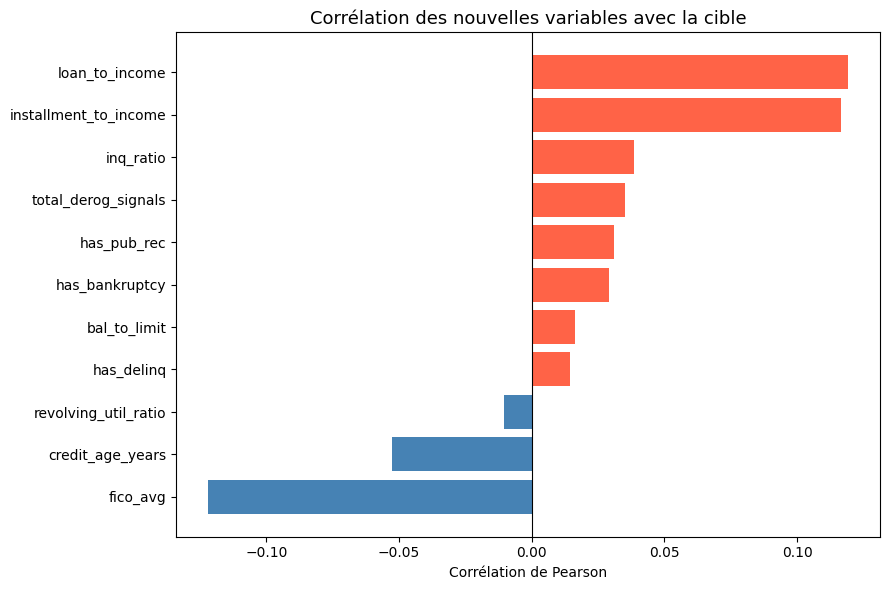

C:\Users\ebene\AppData\Local\Temp\ipykernel_21904\945436431.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([non_defaut, defaut], labels=["Non-défaut", "Défaut"])
C:\Users\ebene\AppData\Local\Temp\ipykernel_21904\945436431.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([non_defaut, defaut], labels=["Non-défaut", "Défaut"])
C:\Users\ebene\AppData\Local\Temp\ipykernel_21904\945436431.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([non_defaut, defaut], labels=["Non-défaut", "Défaut"])


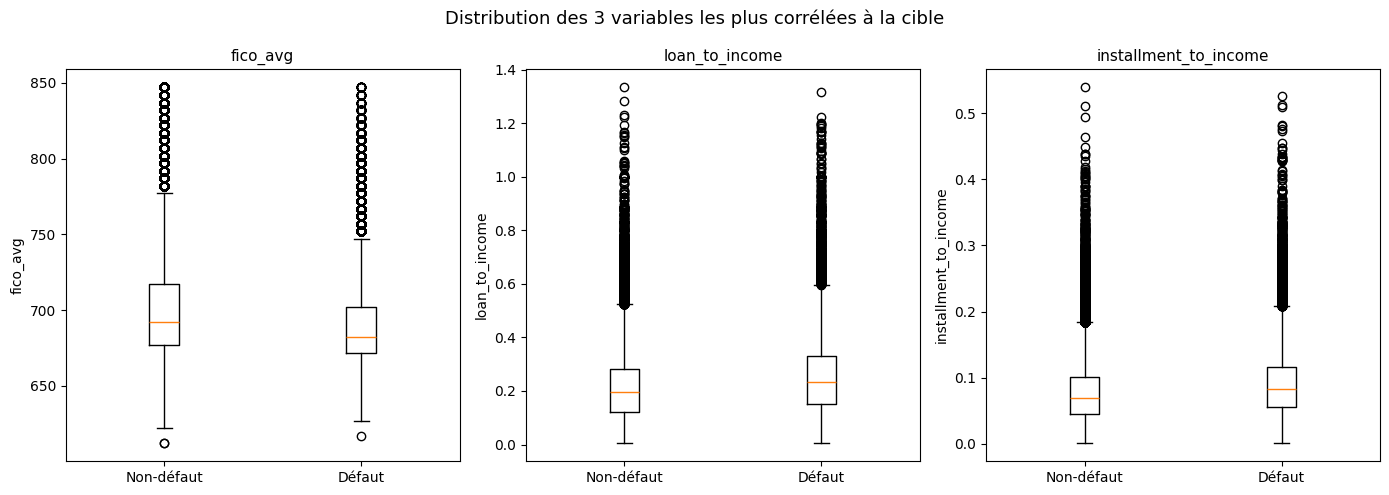

Top 3 variables les plus corrélées : ['fico_avg', 'loan_to_income', 'installment_to_income']


In [24]:
#  Corrélation des nouvelles features avec la cible 

corr_target = (
    df[engineered_features + [target_col]]
    .corr()[target_col]
    .drop(target_col)
    .sort_values()
)

print("Corrélations avec la cible :")
print(corr_target.round(4))

#  Graphique 1 : barplot coloré (positif/négatif) 

colors = ["tomato" if v > 0 else "steelblue" for v in corr_target.values]

plt.figure(figsize=(9, 6))
plt.barh(corr_target.index, corr_target.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Corrélation des nouvelles variables avec la cible", fontsize=13)
plt.xlabel("Corrélation de Pearson")
plt.tight_layout()
plt.show()

#  Graphique 2 : boxplot des 3 variables les plus corrélées 

top_features = corr_target.abs().sort_values(ascending=False).head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, feat in zip(axes, top_features):
    non_defaut = df[df[target_col] == 0][feat]
    defaut     = df[df[target_col] == 1][feat]
    ax.boxplot([non_defaut, defaut], labels=["Non-défaut", "Défaut"])
    ax.set_title(feat, fontsize=11)
    ax.set_ylabel(feat)

plt.suptitle("Distribution des 3 variables les plus corrélées à la cible", fontsize=13)
plt.tight_layout()
plt.show()

print("Top 3 variables les plus corrélées :", top_features)

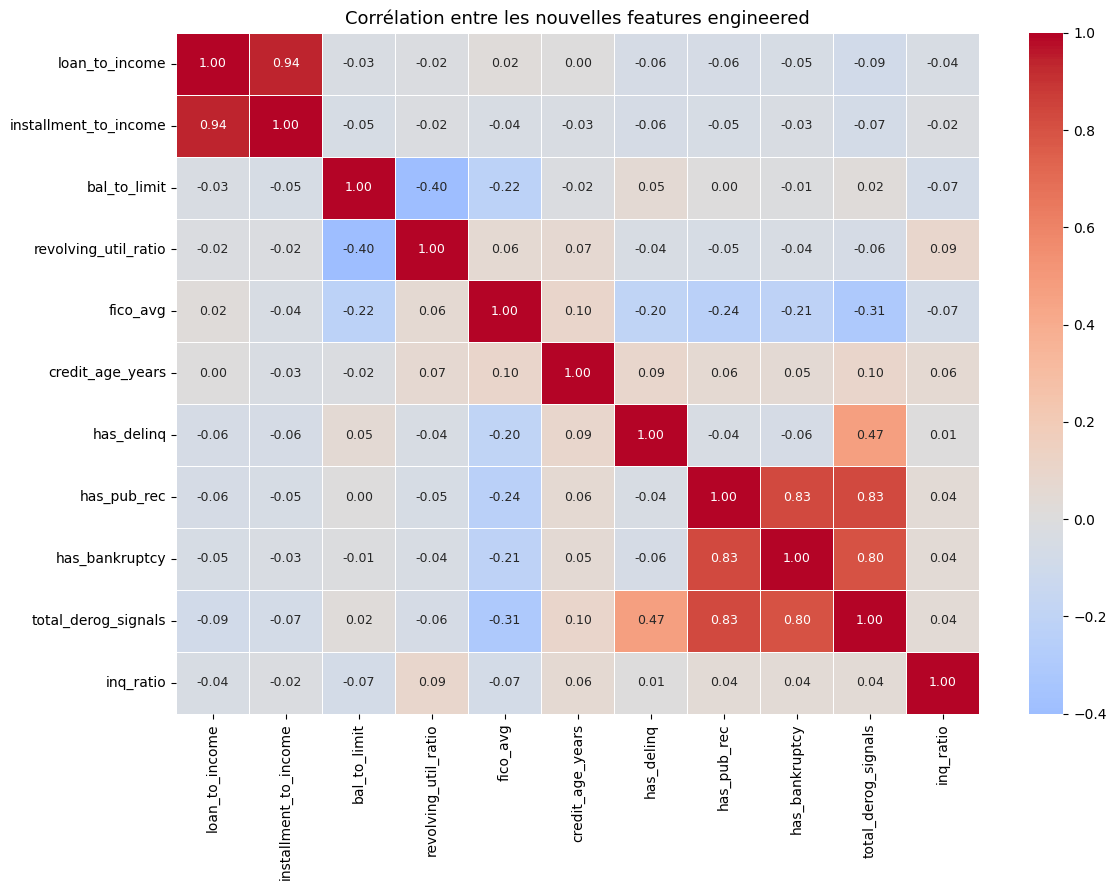

  Paires de features corrélées à plus de 0.7 :
---------------------------------------------
   loan_to_income  ↔  installment_to_income  :  0.94
   has_pub_rec  ↔  has_bankruptcy  :  0.83
   has_pub_rec  ↔  total_derog_signals  :  0.83
   has_bankruptcy  ↔  total_derog_signals  :  0.80


In [25]:
import seaborn as sns

#  Matrice de corrélation entre les nouvelles features 

corr_matrix = df[engineered_features].corr().round(2)

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title("Corrélation entre les nouvelles features engineered", fontsize=13)
plt.tight_layout()
plt.show()

# On affiche les paires fortement corrélées avec un (seuil > 0.7) 

seuil = 0.7

print(f"  Paires de features corrélées à plus de {seuil} :")
print("-" * 45)

found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = abs(corr_matrix.iloc[i, j])
        if val > seuil:
            col_i = corr_matrix.columns[i]
            col_j = corr_matrix.columns[j]
            print(f"   {col_i}  ↔  {col_j}  :  {val:.2f}")
            found = True

if not found:
    print("   Aucune paire fortement corrélée détectée.")

## Binary Encoding

In [26]:
# Le binary encoding (get_dummies) ne dépend pas de la cible,
# donc il peut être fait avant le split sans risque de leakage.

original_cols = df.columns.tolist()
df = pd.get_dummies(df, columns=binary_cat_cols, drop_first=True)

# Identifier les nouvelles colonnes créées par le binary encoding
new_binary_cols = [col for col in df.columns if col not in original_cols]
print(f"Nouvelles colonnes binaires créées : {new_binary_cols}")
print(f"Dimensions après binary encoding : {df.shape}")

df.head().T

Nouvelles colonnes binaires créées : ['term_ 60 months', 'initial_list_status_w', 'disbursement_method_DirectPay']
Dimensions après binary encoding : (1518493, 87)


,0,1,2,3,4
loan_amnt,25000.0,10000.0,35000.0,12000.0,15000.0
installment,771.82,335.65,1198.94,366.37,373.52
home_ownership,MORTGAGE,RENT,MORTGAGE,MORTGAGE,MORTGAGE
annual_inc,170000.0,60000.0,116000.0,200000.0,50000.0
verification_status,Verified,Not Verified,Verified,Source Verified,Source Verified
...,...,...,...,...,...
total_derog_signals,0,0,0,0,0
inq_ratio,0.0,0.0,2.0,2.0,0.0
term_ 60 months,False,False,False,False,True
initial_list_status_w,True,True,False,False,True


## Train / Test split stratifié

In [27]:
stratified = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in stratified.split(df, df[target_col]):
    train_df = df.iloc[train_idx].reset_index(drop=True)
    test_df  = df.iloc[test_idx].reset_index(drop=True)

train_y = train_df[target_col]
test_y  = test_df[target_col]

train_X = train_df.drop(columns=[target_col])
test_X  = test_df.drop(columns=[target_col])

print(f"Train : {train_X.shape} | Ratio défaut : {train_y.mean():.2%}")
print(f"Test  : {test_X.shape}  | Ratio défaut : {test_y.mean():.2%}")





Train : (1214794, 86) | Ratio défaut : 19.13%
Test  : (303699, 86)  | Ratio défaut : 19.13%


### Target Encoding

In [28]:
# Mise à jour multi_cat_cols après les suppressions
multi_cat_cols = [col for col in multi_cat_cols if col in train_X.columns]
print(f"multi_cat_cols mis à jour : {multi_cat_cols}")

# Target Encoding — fit sur train uniquement, transform sur test
encoder = TargetEncoder(cols=multi_cat_cols, smoothing=10)
train_X[multi_cat_cols] = encoder.fit_transform(train_X[multi_cat_cols], train_y)
test_X[multi_cat_cols]  = encoder.transform(test_X[multi_cat_cols])

print(f"Dimensions train : {train_X.shape}")
print(f"Dimensions test  : {test_X.shape}")

multi_cat_cols mis à jour : ['home_ownership', 'verification_status', 'purpose', 'region']
Dimensions train : (1214794, 86)
Dimensions test  : (303699, 86)


## Normalisation

In [29]:
# Colonnes binaires à exclure du scaling
binary_engineered = [
    "has_delinq", "has_pub_rec", 
    "has_bankruptcy", "total_derog_signals"
]

# Colonnes à scaler = toutes sauf les binaires
num_cols_to_scale = [
    c for c in train_X.columns
    if c not in binary_engineered
]

print(f"Colonnes scalées : {len(num_cols_to_scale)}")
print(f"Colonnes exclues : {len(binary_engineered)}")

scaler = StandardScaler()
train_X[num_cols_to_scale] = scaler.fit_transform(train_X[num_cols_to_scale])
test_X[num_cols_to_scale]  = scaler.transform(test_X[num_cols_to_scale])

print("Normalisation appliquée avec succès.")

Colonnes scalées : 82
Colonnes exclues : 4
Normalisation appliquée avec succès.


### Vérification

In [30]:
print(" VÉRIFICATIONS ")
print(f"NaN dans train_X : {train_X.isnull().sum().sum()}")
print(f"NaN dans test_X  : {test_X.isnull().sum().sum()}")
print(f"Colonnes train_X : {train_X.shape[1]}")
print(f"Colonnes test_X  : {test_X.shape[1]}")
print(f"Colonnes identiques : {list(train_X.columns) == list(test_X.columns)}")

 VÉRIFICATIONS 
NaN dans train_X : 0
NaN dans test_X  : 0
Colonnes train_X : 86
Colonnes test_X  : 86
Colonnes identiques : True


In [31]:
train_X.to_parquet("DATA/03_train_X.parquet")
train_y.to_frame().to_parquet("DATA/03_train_y.parquet")
test_X.to_parquet("DATA/03_test_X.parquet")
test_y.to_frame().to_parquet("DATA/03_test_y.parquet")

#Sauvegarde des transformateurs
joblib.dump(encoder, "DATA/03_encoder.pkl")
joblib.dump(scaler, "DATA/03_scaler.pkl")

print(" Tous les fichiers ont été sauvegardés avec succès !")
print("   - DATA/03_train_X.parquet")
print("   - DATA/03_train_y.parquet")
print("   - DATA/03_test_X.parquet")
print("   - DATA/03_test_y.parquet")
print("   - DATA/03_encoder.pkl")
print("   - DATA/03_scaler.pkl")

 Tous les fichiers ont été sauvegardés avec succès !
   - DATA/03_train_X.parquet
   - DATA/03_train_y.parquet
   - DATA/03_test_X.parquet
   - DATA/03_test_y.parquet
   - DATA/03_encoder.pkl
   - DATA/03_scaler.pkl
